In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

Max folder: 485


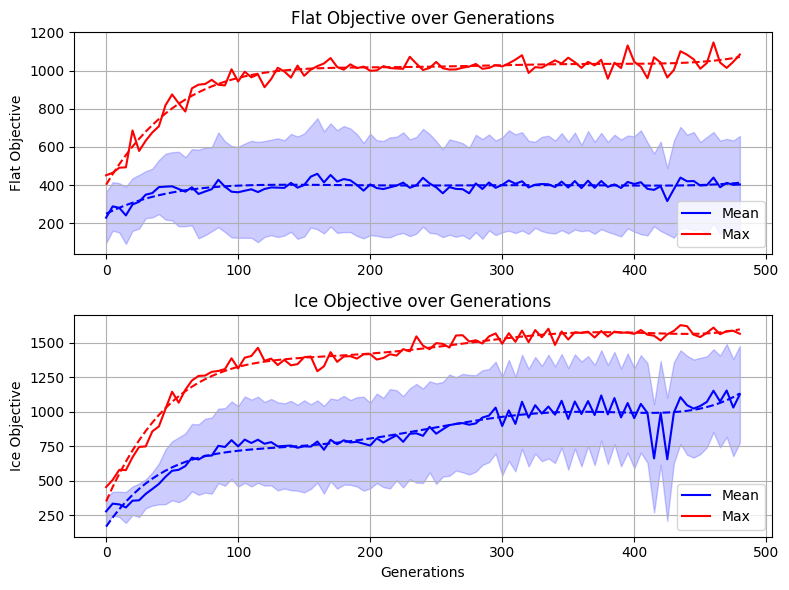

In [13]:
# plot mean and max of both objectives in f over generations. 
# For that read folders with f_best = np.load("results/20260401_113146_nsga_ckpts/i/f.npy") 
# for i in range(0, 600, 10) and plot the mean and max of f on y and generations on x on two subplots.
flat_mean = []
flat_max = []
flat_std = []
ice_mean = []
ice_max = []
ice_std = []


path = "results/20260402_142229_nsga_ckpts"

max_folder = max([int(d) for d in os.listdir(path) if d.isdigit()])
print(f"Max folder: {max_folder}")

fig,axs = plt.subplots(2,1, figsize=(8, 6))
for i in range(0, max_folder, 5):
    f = np.load(f"{path}/{i}/f.npy")
    flat_mean.append(np.mean(f, axis=0)[0])
    flat_max.append(np.max(f, axis=0)[0])
    ice_mean.append(np.mean(f, axis=0)[1])
    ice_max.append(np.max(f, axis=0)[1])
    flat_std.append(np.std(f, axis=0)[0])
    ice_std.append(np.std(f, axis=0)[1])

generations = np.arange(0, max_folder, 5)

axs[0].plot(generations, flat_mean, label="Mean", color="blue")
axs[0].plot(generations, flat_max, label="Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, flat_mean, 5)
p = np.poly1d(z)
axs[0].plot(generations, p(generations), linestyle="--", color="blue")
z = np.polyfit(generations, flat_max, 5)
p = np.poly1d(z)
axs[0].plot(generations, p(generations), linestyle="--", color="red")    
axs[0].set_ylabel("Flat Objective")
axs[0].legend(loc="lower right")
axs[0].fill_between(generations, np.array(flat_mean) - np.array(flat_std), np.array(flat_mean) + np.array(flat_std), alpha=0.2, color="blue")
axs[0].grid("on")
axs[0].set_title("Flat Objective over Generations")


axs[1].plot(generations, ice_mean, label="Mean", color="blue")
axs[1].plot(generations, ice_max, label="Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, ice_mean, 5)
p = np.poly1d(z)
axs[1].plot(generations, p(generations), linestyle="--", color="blue")
z = np.polyfit(generations, ice_max, 5)
p = np.poly1d(z)
axs[1].plot(generations, p(generations), linestyle="--", color="red")
axs[1].set_xlabel("Generations")
axs[1].set_ylabel("Ice Objective")
axs[1].legend(loc="lower right")
axs[1].grid("on")

# plot the std of both objectives in f over generations around the mean as a shaded area
axs[1].fill_between(generations, np.array(ice_mean) - np.array(ice_std), np.array(ice_mean) + np.array(ice_std), alpha=0.2, color="blue")
axs[1].set_title("Ice Objective over Generations")

fig.tight_layout()


In [15]:
from Challenge2 import plot_pareto_fronts_from_checkpoint, replay_checkpoint, plot_fitness
path = "results/20260402_142229_nsga_ckpts"

In [18]:
plot_fitness(np.load(f"{path}/full_f.npy"), path)

Fitness plot saved to: results/20260402_142229_nsga_ckpts/fitness_plot.pdf


Best Flat Terrain Individual: 199 with fitness [1042.60284054 1038.07608161]
Best Ice Terrain Individual: 132 with fitness [ 214.6088208  1574.58976929]


/home/finckh/miniconda3/envs/evorob/lib/python3.10/site-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
/home/finckh/miniconda3/envs/evorob/lib/python3.10/site-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


FatalError: an OpenGL platform library has not been loaded into this process, this most likely means that a valid OpenGL context has not been created before mjr_makeContext was called

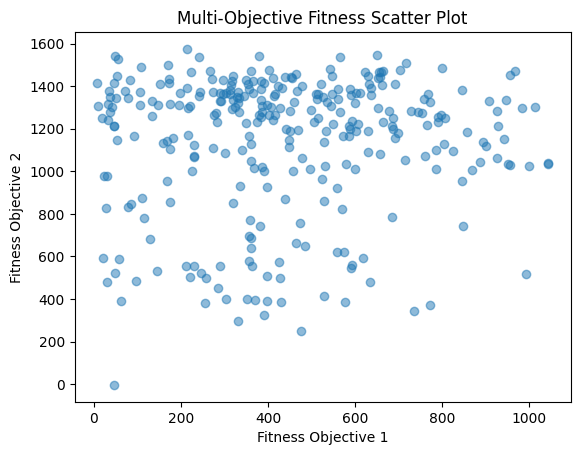

In [10]:
replay_checkpoint("results/20260402_142229_nsga_ckpts/480")

In [9]:
plot_pareto_fronts_from_checkpoint(path)

Pareto front plot saved to: results/20260402_142229_nsga_ckpts/pareto_fronts.pdf


In [ ]:
full_f = np.load(f"{path}/full_f.npy").reshape((-1,2))
full_x = np.load(f"{path}/full_x.npy").reshape((-1,560))
idx_flat = np.argmax(full_f[:,0], axis=0)
idx_ice = np.argmax(full_f[:,1], axis=0)
print(f"Best flat objective: {full_f[idx_flat, 0]}, corresponding ice objective: {full_f[idx_flat, 1]}")
print(f"Best ice objective: {full_f[idx_ice, 1]}, corresponding flat objective: {full_f[idx_ice, 0]}")

Best flat objective: 1135.099972651839, corresponding ice objective: 1161.402665652234
Best ice objective: 1629.2584213520468, corresponding flat objective: 93.81218429700745


In [14]:
full_f.shape, full_x.shape

((136800, 2), (456, 300, 560))

In [29]:
specialist_flat = full_x[idx_flat]
specialist_ice = full_x[idx_ice]
# save at path/specialist_flat.npy and path/specialist_ice.npy
np.save(f"{path}/flat_specialist/x.npy", np.array(specialist_flat))
np.save(f"{path}/ice_specialist/x.npy", np.array(specialist_ice))

In [27]:
np.array(specialist_flat).shape

(560,)

In [30]:
replay_checkpoint(f"{path}/flat_specialist")

TypeError: object of type 'numpy.float64' has no len()

In [28]:
np.load("results/20260402_142229_nsga_ckpts/465/x_best.npy").shape

(560,)

In [1]:
import os

# os.environ.setdefault("MUJOCO_GL", "egl")

from datetime import datetime
from pathlib import Path
from typing import Optional, Tuple

import imageio
import matplotlib.pyplot as plt
import numpy as np

from evorob.algorithms.nsga import NSGAII
from evorob.utils.filesys import get_last_checkpoint_dir
from evorob.world.ant_multi_world import AntMultiWorld
from evorob.world.ant_world import AntFlatWorld
from evorob.world.envs.ant_flat import AntFlatEnvironment
from evorob.world.robot.controllers.mlp import NeuralNetworkController
from evorob.world.robot.controllers.sinoid import OscillatoryController
from evorob.world.robot.controllers.mlp import NeuralNetworkController
from Challenge2 import plot_pareto_fronts_from_checkpoint, replay_checkpoint, _run_episodes, _record_video

In [ ]:
n_episodes: int = 256  # DO NOT CHANGE!
max_episode_steps: int = 1000  # DO NOT CHANGE!
seed: int = 0  # DO NOT CHANGE!

# --- Load best genotype from checkpoint ---
path = "results/20260402_142229_nsga_ckpts/flat_specialist/x.npy"

x_best_path = os.path.join(path, "flat_specialist/x.npy") 


genotype = np.load(x_best_path)
print(f"Loaded genotype from: {x_best_path}  (shape: {genotype.shape})")

controller = NeuralNetworkController(input_size=27, output_size=8, hidden_size=16)
print(f"Controller: NeuralNetworkController  |  Parameters: {controller.n_params}\n")

# --- Evaluate on both environments ---
terrains = {
    "flat": "ant_flat_terrain.xml",
    "ice": "ant_ice_terrain.xml",
}
results = {}

for terrain_name, robot_path in terrains.items():
    print(f"Evaluating on {terrain_name} terrain ({n_episodes} episodes)...")
    env = AntFlatEnvironment(robot_path=robot_path)
    rewards = _run_episodes(
        env, controller, genotype, n_episodes, max_episode_steps, seed
    )
    env.close()

    results[terrain_name] = {
        "rewards": rewards,
        "mean": float(np.mean(rewards)),
        "std": float(np.std(rewards)),
        "best": float(np.max(rewards)),
        "worst": float(np.min(rewards)),
        "median": float(np.median(rewards)),
    }
    r = results[terrain_name]
    print(
        f"  {terrain_name.capitalize():5s}: mean={r['mean']:.2f} +/- {r['std']:.2f}  "
        f"best={r['best']:.2f}  worst={r['worst']:.2f}"
    )

# --- Record one video per terrain ---
os.makedirs(path, exist_ok=True)
for terrain_name, robot_path in terrains.items():
    video_path = os.path.join(path, f"evaluation_{terrain_name}.mp4")
    _record_video(
        AntFlatEnvironment, robot_path, controller, genotype,
        max_episode_steps, seed, video_path,
    )

# --- Save score file with summary ---
score_path = os.path.join(path, "evaluation_score.txt")
with open(score_path, "w") as f:
    f.write("=" * 50 + "\n")
    f.write("MICRO-515 Challenge 2 - Evaluation Results\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Controller type : NeuralNetworkController\n")
    f.write(f"Checkpoint      : {path}\n")
    f.write(f"Episodes/terrain: {n_episodes}\n\n")

    # Summary table
    f.write("=" * 60 + "\n")
    f.write("SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(f"{'Terrain':<8s} {'Mean':>8s} {'Std':>8s} {'Best':>8s} {'Worst':>8s} {'Median':>8s}\n")
    f.write("-" * 60 + "\n")
    for terrain_name in terrains:
        r = results[terrain_name]
        f.write(
            f"{terrain_name.upper():<8s} {r['mean']:8.2f} {r['std']:8.2f} "
            f"{r['best']:8.2f} {r['worst']:8.2f} {r['median']:8.2f}\n"
        )
    f.write("\n")

    # Per-episode details
    for terrain_name in terrains:
        r = results[terrain_name]
        f.write("-" * 50 + "\n")
        f.write(f"{terrain_name.upper()} TERRAIN — Per-episode rewards\n")
        f.write("-" * 50 + "\n")
        for i, rew in enumerate(r["rewards"]):
            f.write(f"  Episode {i + 1:3d}: {rew:10.2f}\n")
        f.write("\n")

print(f"\nScore saved to: {score_path}")
print(f"\n{'=' * 50}")
print(f"  FLAT : {results['flat']['mean']:.2f} +/- {results['flat']['std']:.2f}  (best: {results['flat']['best']:.2f})")
print(f"  ICE  : {results['ice']['mean']:.2f} +/- {results['ice']['std']:.2f}  (best: {results['ice']['best']:.2f})")
print(f"{'=' * 50}")

Loaded genotype from: results/20260402_142229_nsga_ckpts/flat_specialist/x.npy  (shape: (560,))
Controller: NeuralNetworkController  |  Parameters: 560

Evaluating on flat terrain (256 episodes)...
  Flat : mean=778.44 +/- 482.98  best=2377.78  worst=-16.82
Evaluating on ice terrain (256 episodes)...


: 